In [1]:
# Setup: install packages and import everything used in the notebook.
%pip install ipykernel pandas numpy scipy scikit-learn matplotlib seaborn wordcloud gensim vaderSentiment nltk

# Core data handling
import re
import pandas as pd
import numpy as np
from scipy import stats   # used for the Welch t-test on sentiment

# IO and NLP
import tarfile      # read the lyrics tar.gz directly
import gensim       # for Word2Vec
import nltk         # for the english stopword list
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download the english stopwords once
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

# Machine learning tools
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler   # scale features before PCA
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Reproducibility
np.random.seed(42)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /home/achilleas2005/6o_Εξαμηνο/Data_Mining/TED/sdi2300107/.venv312/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


# Εξόρυξη Γνώσης από Μουσικά Δεδομένα (Audio & Lyrics)

**Ομάδα:**
* Παναγιώτης Μακαρόνας (AM: sdi2300107)
* Αχιλλέας Νιανιακούδης-Κοέν (AM: sdi2300138)

## 1. Συλλογή Δεδομένων (Data collection)
Σε αυτό το κελί φορτώνονται τα δεδομένα, εφαρμόζεται το φιλτράρισμα στα Top-5 Genres και πραγματοποιείται το intersection των αρχείων.

In [2]:
# File paths
genres_path = "data/id_genres.csv"
info_path = "data/id_information.csv"
mfcc_path = "data/id_mfcc_stats.tsv.bz2"
tags_path = "data/id_tags.csv"
lyrics_archive = "data/processed_lyrics.tar.gz"

# Small TSV files (despite the .csv extension they are tab-separated)
df_genres = pd.read_csv(genres_path, sep='\t')
df_info = pd.read_csv(info_path, sep='\t')
df_tags = pd.read_csv(tags_path, sep='\t')

# Read the large MFCC file in 2000-row chunks to keep memory low
mfcc_chunks = []
for chunk in pd.read_csv(mfcc_path, sep='\t', compression='bz2', chunksize=2000):
    mfcc_chunks.append(chunk)
df_mfcc = pd.concat(mfcc_chunks, ignore_index=True)

# Make sure the song id column is named 'id' so merges are unambiguous
mfcc_id_col = df_mfcc.columns[0]
if mfcc_id_col != 'id':
    df_mfcc = df_mfcc.rename(columns={mfcc_id_col: 'id'})

# Drop a possible 'genre' column inside MFCC to avoid merge collisions
if 'genre' in df_mfcc.columns:
    df_mfcc = df_mfcc.drop(columns=['genre'])

# Each row has comma-separated genres; explode to one (song, genre) pair per row
df_genres['genre'] = df_genres['genres'].str.split(',')
df_genres = df_genres.explode('genre')
df_genres['genre'] = df_genres['genre'].str.strip()

# Keep only the Top-5 most frequent genres
top5 = df_genres['genre'].value_counts().head(5).index.tolist()
df_genres = df_genres[df_genres['genre'].isin(top5)]
print(f"Top-5 genres: {top5}")

# One genre per song (first match)
df_genres = df_genres.drop_duplicates(subset='id', keep='first')

# Explicit (id -> genre) dict so we can re-attach the label after any merge
genre_map = dict(zip(df_genres['id'].astype(str), df_genres['genre']))

# Intersection: only keep songs present in genres AND mfcc AND lyrics
genre_ids = set(df_genres['id'].astype(str))
mfcc_ids = set(df_mfcc['id'].astype(str))
common_ids = genre_ids & mfcc_ids

# Stream the lyrics tar.gz, extracting only files for songs we actually need
lyrics_dict = {}
with tarfile.open(lyrics_archive, 'r:gz') as tar:
    for member in tar:
        if not member.isfile():
            continue
        song_id = member.name.split('/')[-1].replace('.txt', '')
        if song_id in common_ids:
            f = tar.extractfile(member)
            if f:
                lyrics_dict[song_id] = f.read().decode('utf-8', errors='ignore')

df_lyrics = pd.DataFrame(list(lyrics_dict.items()), columns=['id', 'lyrics'])
final_ids = common_ids & set(df_lyrics['id'])

# Build df from a known-good base (lyrics) and attach genre via the map
df = df_lyrics[df_lyrics['id'].isin(final_ids)].copy()
df['id'] = df['id'].astype(str)
df['genre'] = df['id'].map(genre_map)

# Merge MFCC features. suffixes=('', '_mfcc') protects our existing columns
df_mfcc['id'] = df_mfcc['id'].astype(str)
df = df.merge(df_mfcc, on='id', how='left', suffixes=('', '_mfcc'))

# Re-assert genre after the merge (defensive against any version-specific quirks)
df['genre'] = df['id'].map(genre_map)

assert 'genre' in df.columns
assert df['genre'].isna().sum() == 0

# Balanced sampling: up to 2000 songs per genre
SAMPLE_PER_GENRE = 2000
df_sampled = []
for g in df['genre'].unique():
    genre_df = df[df['genre'] == g]
    sampled = genre_df.sample(min(len(genre_df), SAMPLE_PER_GENRE), random_state=42)
    df_sampled.append(sampled)
df = pd.concat(df_sampled, ignore_index=True)

# De-fragment after all the column work to silence pandas PerformanceWarning
df = df.copy()

print(f"\nFinal dataset: {len(df)} songs across {df['genre'].nunique()} genres")
print(df['genre'].value_counts())
print(df[['id', 'genre', 'lyrics']].head())


Top-5 genres: ['rock', 'pop', 'electronic', 'alternative rock', 'indie rock']



Final dataset: 10000 songs across 5 genres
genre
rock                2000
alternative rock    2000
pop                 2000
indie rock          2000
electronic          2000
Name: count, dtype: int64
                 id genre                                             lyrics
0  uORMwZEydnnPWCf3  rock  move talk time think worri everyth fine fine g...
1  tF4fFZp2rIPnr2T7  rock  larri call load smoke want lose coupl day prob...
2  yKqVJ4TBJzPDJABc  rock  light green green dark green brown everi life ...
3  NwbcLd9ls0zUSu8E  rock  east mode everybodi strike pose everybodi tax ...
4  zGdLJNjLygap1tYJ  rock  say exist help say exist protect know stop kno...


## 2. Εξαγωγή Χαρακτηριστικών & Embeddings (Feature Extraction)
Εδώ δημιουργούνται οι διανυσματικές αναπαραστάσεις για το κείμενο (Word2Vec, με average-pooling των word vectors ανά τραγούδι) και για τον ήχο (StandardScaler + PCA στα MFCCs ώστε όλα τα features να έχουν την ίδια κλίμακα πριν την μείωση διαστάσεων).


In [3]:
# Text embeddings: Word2Vec with average-pooling per song
from gensim.models import Word2Vec

# Simple regex tokenizer (lowercase, alphanumeric + apostrophe).
# Better than .split() because it strips punctuation cleanly.
_TOKEN_RE = re.compile(r"[a-z0-9']+")
def tokenize(text):
    return _TOKEN_RE.findall(text.lower())

tokenized = df['lyrics'].apply(tokenize).tolist()

# 128-dim vectors, window of 5, drop words seen only once. workers=1 + seed
# makes training reproducible (small enough corpus for that to be fine).
w2v_model = Word2Vec(sentences=tokenized, vector_size=128,
                     window=5, min_count=2, workers=1, seed=42, epochs=10)
print(f"Word2Vec vocabulary size: {len(w2v_model.wv)}")

def song_text_embedding(words, model):
    # Average all known word vectors. Empty / all-OOV songs become zero vectors.
    vecs = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

text_embeddings = np.vstack(
    [song_text_embedding(tok, w2v_model) for tok in tokenized]
)
print(f"Text embeddings shape: {text_embeddings.shape}")

# Audio embeddings: StandardScaler + PCA on the MFCC stats.
# Everything that is not a bookkeeping/text column is an MFCC feature.
mfcc_cols = [c for c in df.columns if c not in ['id', 'genre', 'lyrics', 'genres']]
mfcc_matrix = df[mfcc_cols].values.astype(np.float32)

# A few MFCC stats can be NaN/Inf for very short tracks. Replace with 0.
mfcc_matrix = np.nan_to_num(mfcc_matrix, nan=0.0, posinf=0.0, neginf=0.0)

# Standardize before PCA so no single feature dominates the variance.
scaler = StandardScaler()
mfcc_scaled = scaler.fit_transform(mfcc_matrix)

# Keep enough PCA components to explain 95% of variance.
pca = PCA(n_components=0.95, random_state=42)
audio_embeddings = pca.fit_transform(mfcc_scaled)
print(f"Audio PCA: {mfcc_matrix.shape[1]} dims -> {audio_embeddings.shape[1]} dims "
      f"({pca.n_components_} components, 95% variance)")

# Attach both embeddings to df in one shot to avoid fragmentation.
df = pd.concat([
    df,
    pd.DataFrame({'text_emb': list(text_embeddings),
                  'audio_emb': list(audio_embeddings)}, index=df.index),
], axis=1).copy()
print("Embeddings stored in DataFrame")


Word2Vec vocabulary size: 12413


Text embeddings shape: (10000, 128)
Audio PCA: 104 dims -> 79 dims (79 components, 95% variance)
Embeddings stored in DataFrame


## 3. Οπτικοποίηση και Ανάλυση (Exploratory Data Analysis - EDA)
Ανάλυση των tags, word clouds, 2D projections (PCA/t-SNE) και Cosine Similarity.

Tag-set Jaccard similarity between Top-5 genres (lower = more different):
  alternative rock vs electronic      Jaccard=0.132  Distance=0.868
  alternative rock vs indie rock      Jaccard=0.277  Distance=0.723
  alternative rock vs pop             Jaccard=0.200  Distance=0.800
  alternative rock vs rock            Jaccard=0.463  Distance=0.537
  electronic     vs indie rock      Jaccard=0.111  Distance=0.889
  electronic     vs pop             Jaccard=0.250  Distance=0.750
  electronic     vs rock            Jaccard=0.132  Distance=0.868
  indie rock     vs pop             Jaccard=0.176  Distance=0.824
  indie rock     vs rock            Jaccard=0.304  Distance=0.696
  pop            vs rock            Jaccard=0.277  Distance=0.723

Most different pair: 'electronic' vs 'indie rock' (distance=0.889)


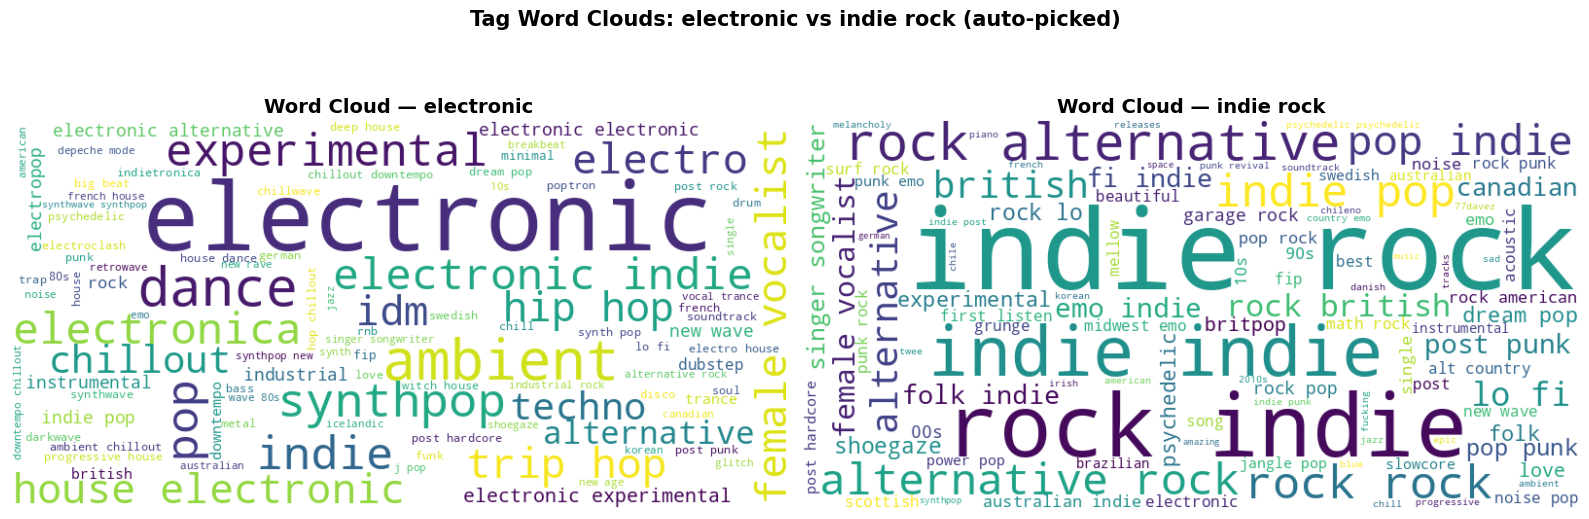

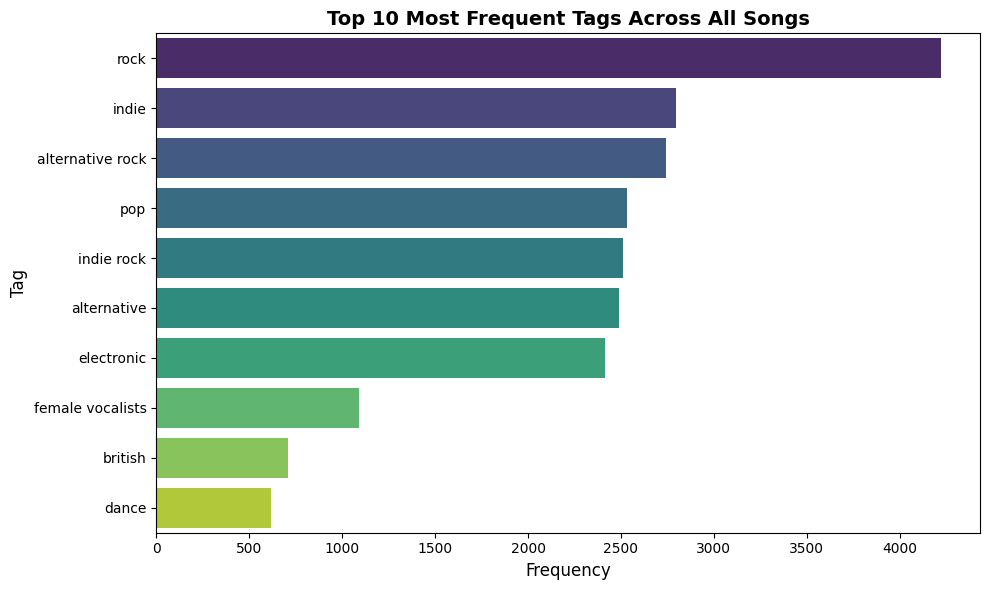

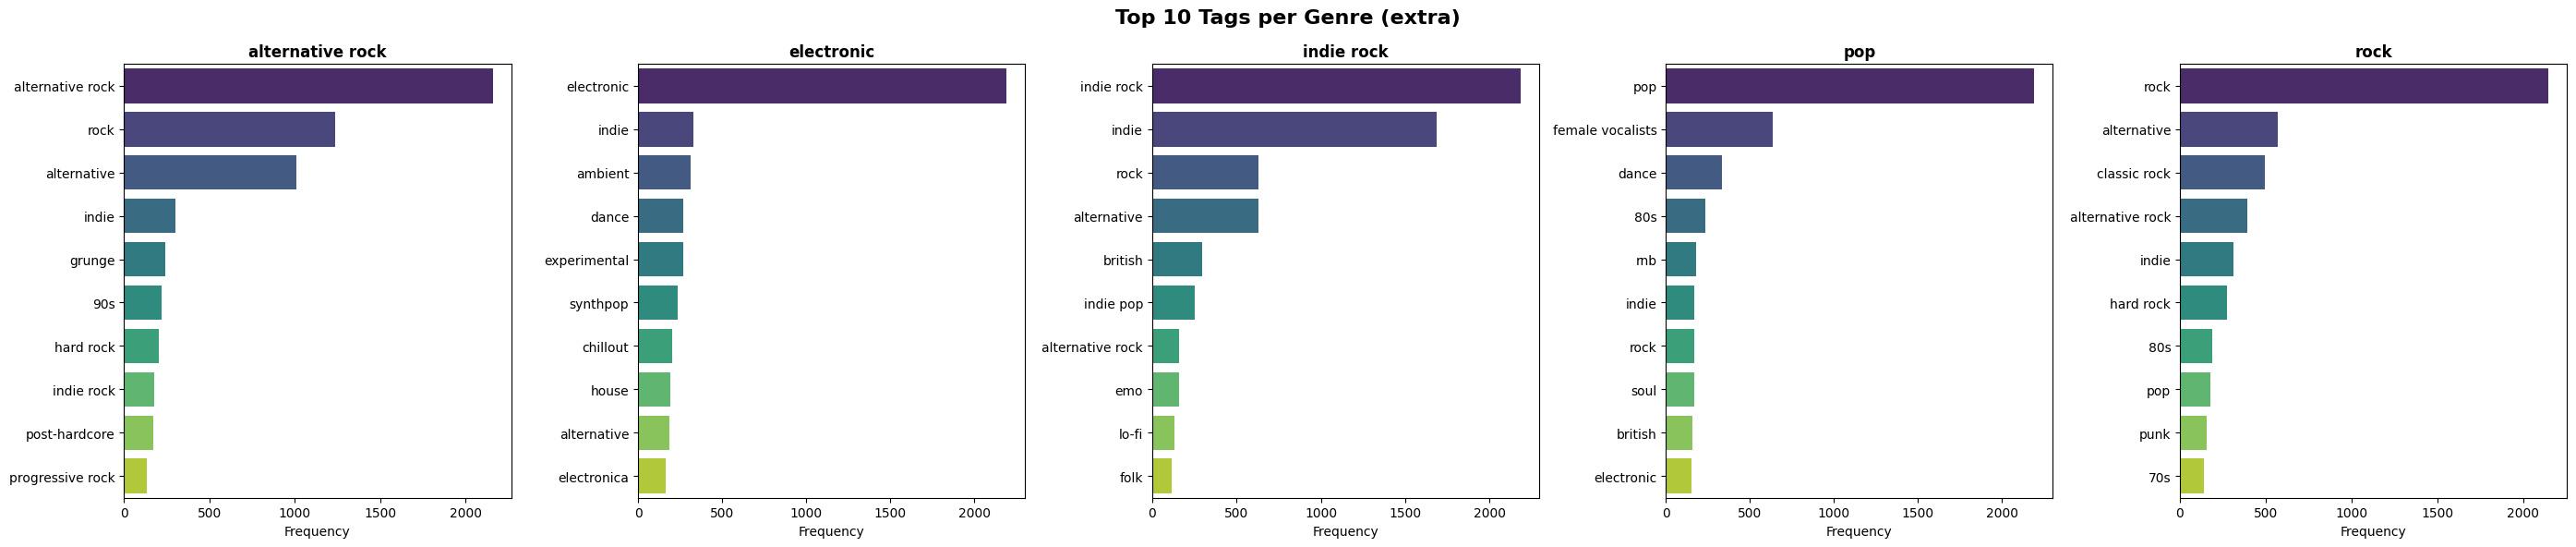

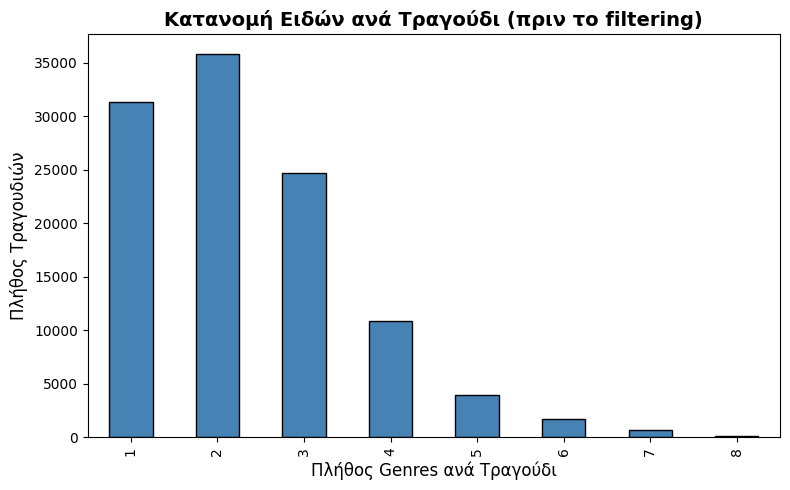

Μέσος αριθμός genres/τραγούδι: 2.35
Max genres σε ένα τραγούδι: 8


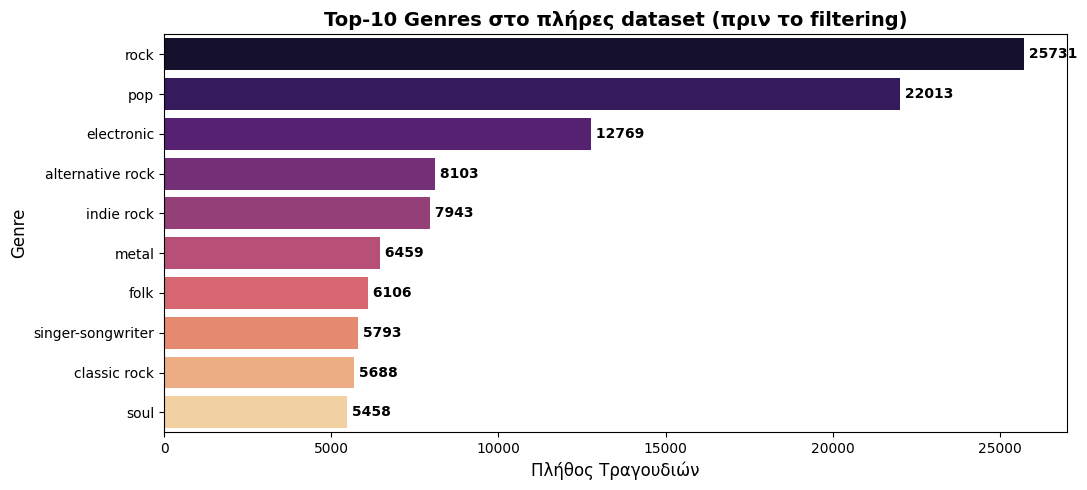

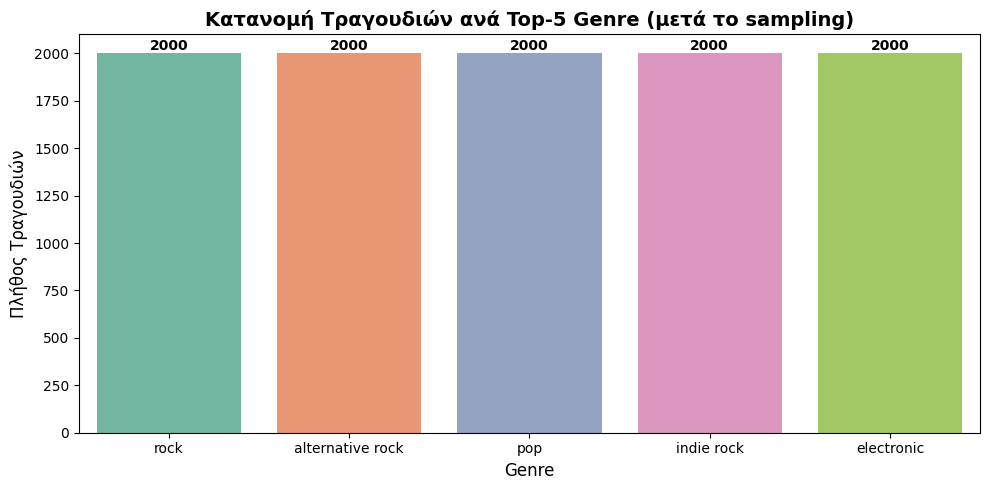

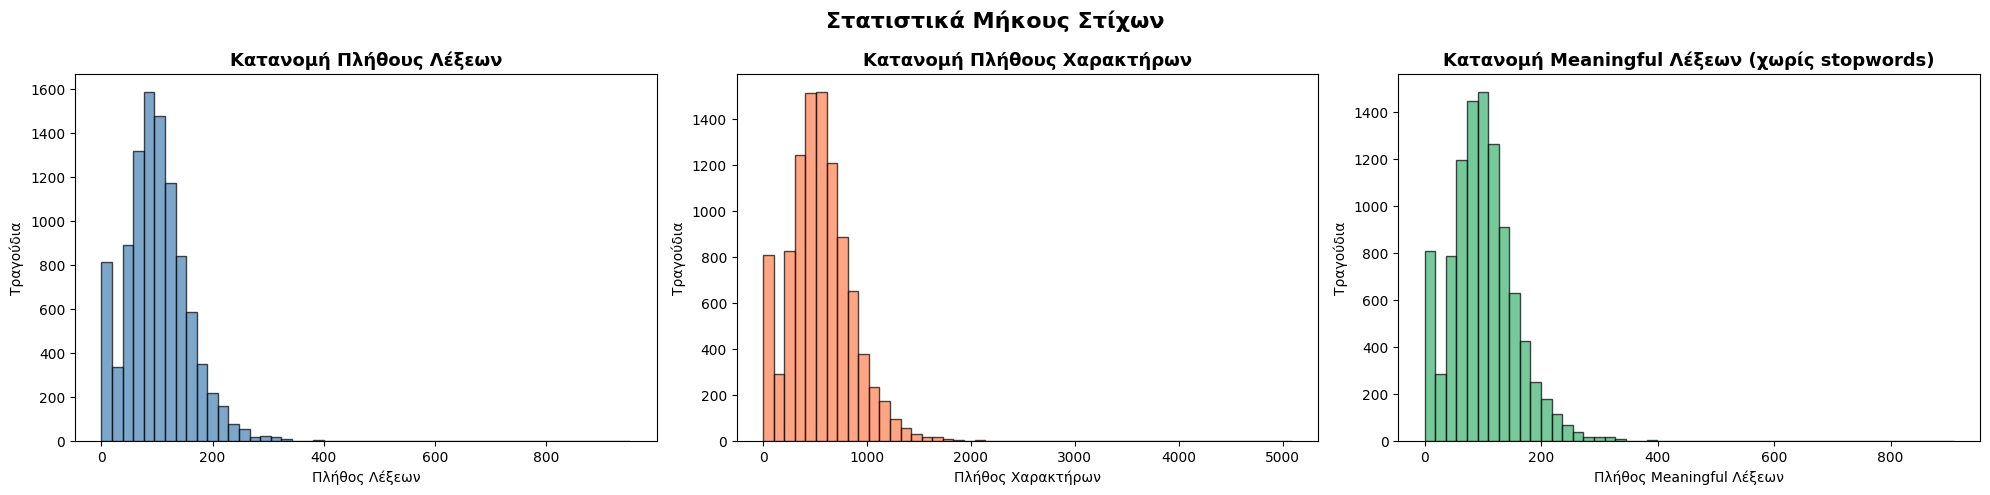

Μέση λέξεις/τραγούδι: 100, Μέσοι χαρακτήρες: 549, Μέσες meaningful λέξεις: 100


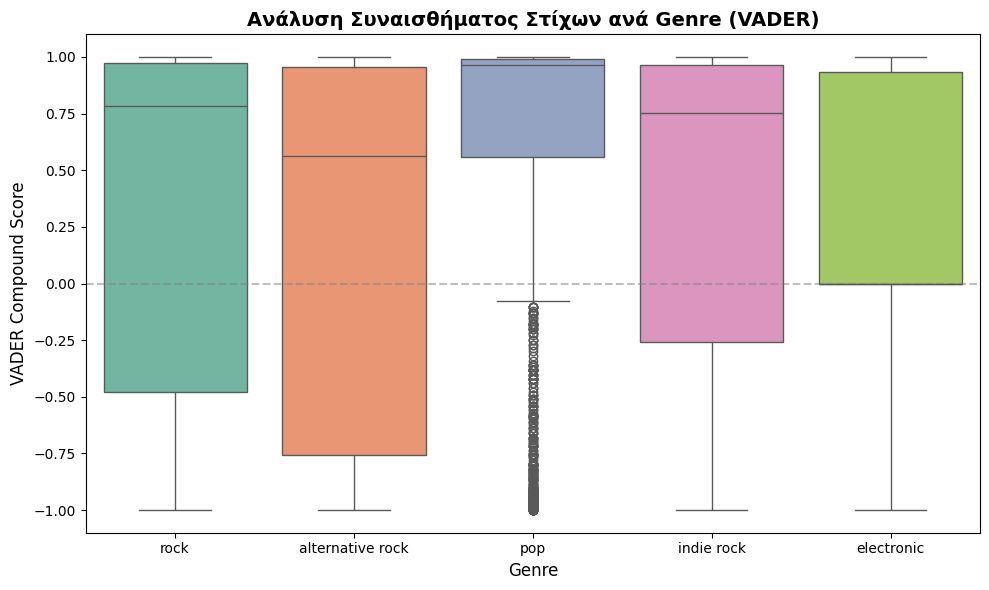

Μέσο Sentiment (compound) ανά genre:
                   mean  median    std
genre                                 
alternative rock  0.199   0.561  0.795
electronic        0.249   0.000  0.649
indie rock        0.356   0.754  0.727
pop               0.590   0.964  0.675
rock              0.316   0.784  0.774

Welch t-test (pop vs rock sentiment):
  t = +11.938,  p-value = 2.691e-32
  mean(pop) - mean(rock) = +0.274
  ΥΠΟΘΕΣΗ ΕΠΙΒΕΒΑΙΩΝΕΤΑΙ: το pop είναι σημαντικά πιο θετικό (α=0.05).


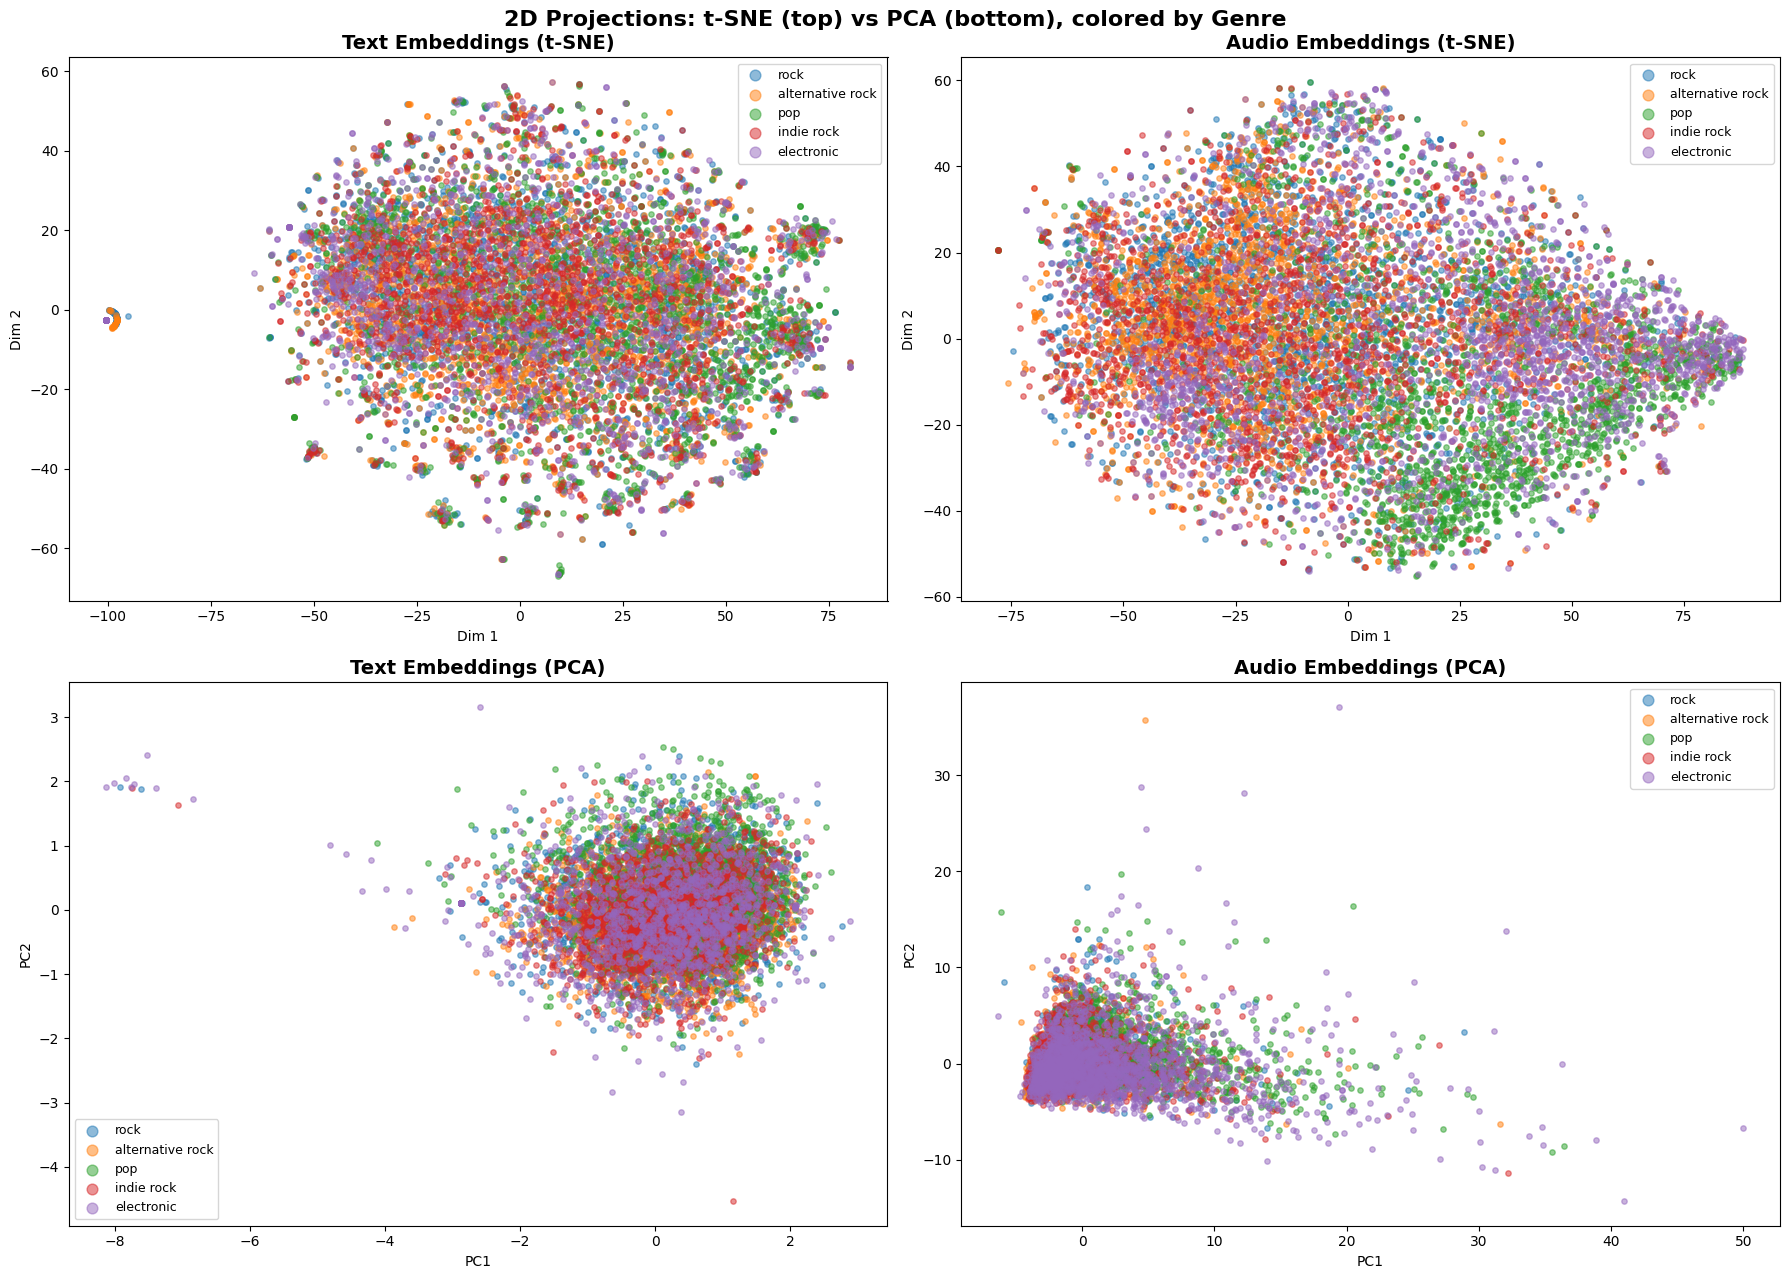


QUERY: [alternative rock] Sonic Youth — 'Cross the Breeze  (id=Hqxs2hQUU2qLd1qH)

  Top 5 by TEXT (lyrics) similarity:
    1. [alternative rock] Sonic Youth — 'Cross The Breeze (Live)                   sim=+1.000
    2. [rock        ] Sunrise Avenue — 6 - 0                                   sim=+0.924
    3. [alternative rock] My Chemical Romance — Planetary [GO!]                    sim=+0.921
    4. [alternative rock] Kongos — I Want to Know                                  sim=+0.919
    5. [rock        ] Mac DeMarco — The Stars Keep On Calling My Name          sim=+0.917

  Top 5 by AUDIO (MFCC) similarity:
    1. [alternative rock] Finch — Grey Matter                                      sim=+0.607
    2. [rock        ] John Frusciante — Look On                                sim=+0.587
    3. [indie rock  ] Bloc Party — 3x3                                         sim=+0.550
    4. [rock        ] Ozzy Osbourne — A.V.H.                                   sim=+0.532
    5. [rock     

In [4]:
# Attach the user tags to each song (left-join keeps every song)
df_tags['id'] = df_tags['id'].astype(str).str.strip()
df_with_tags = df.merge(df_tags, on='id', how='left')

# 3a. Word clouds for the two most-different genres.
# We pick the pair automatically using Jaccard distance on each genre's
# top-30 tags (lower Jaccard = more different).
genre_top_tag_sets = {}
for g in df['genre'].unique():
    g_tag_strings = df_with_tags[df_with_tags['genre'] == g]['tags'].dropna().astype(str)
    g_tags_flat = g_tag_strings.str.split(',').explode().str.strip()
    genre_top_tag_sets[g] = set(g_tags_flat.value_counts().head(30).index)

print("Tag-set Jaccard similarity between Top-5 genres (lower = more different):")
genre_list = sorted(genre_top_tag_sets)
best_pair, best_dist = None, -1.0
for i in range(len(genre_list)):
    for j in range(i + 1, len(genre_list)):
        a, b = genre_top_tag_sets[genre_list[i]], genre_top_tag_sets[genre_list[j]]
        jacc = len(a & b) / len(a | b) if (a | b) else 0.0
        dist = 1.0 - jacc
        print(f"  {genre_list[i]:14s} vs {genre_list[j]:14s}  Jaccard={jacc:.3f}  Distance={dist:.3f}")
        if dist > best_dist:
            best_dist, best_pair = dist, (genre_list[i], genre_list[j])

genre_a, genre_b = best_pair
print(f"\nMost different pair: '{genre_a}' vs '{genre_b}' (distance={best_dist:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, genre in zip(axes, [genre_a, genre_b]):
    # Concatenate all tag strings for this genre; WordCloud counts internally
    genre_tags = df_with_tags[df_with_tags['genre'] == genre]['tags'].dropna()
    all_tags_text = ' '.join(genre_tags.astype(str))
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap='viridis', max_words=100).generate(all_tags_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"Word Cloud — {genre}", fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle(f"Tag Word Clouds: {genre_a} vs {genre_b} (auto-picked)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 3b. Top-10 tags across the whole dataset (required by the assignment)
all_tags = df_with_tags['tags'].dropna().astype(str)
tag_series = all_tags.str.split(',').explode().str.strip()
tag_counts = tag_series.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=tag_counts.values, y=tag_counts.index, hue=tag_counts.index,
            palette='viridis', legend=False)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Tag", fontsize=12)
plt.title("Top 10 Most Frequent Tags Across All Songs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top-10 tags per genre (extra)
fig, axes = plt.subplots(1, 5, figsize=(28, 6), sharey=False)
for ax, genre in zip(axes, sorted(df['genre'].unique())):
    genre_tags = df_with_tags[df_with_tags['genre'] == genre]['tags'].dropna().astype(str)
    tags_flat = genre_tags.str.split(',').explode().str.strip()
    top10 = tags_flat.value_counts().head(10)
    sns.barplot(x=top10.values, y=top10.index, hue=top10.index,
                palette='viridis', legend=False, ax=ax)
    ax.set_title(genre, fontsize=12, fontweight='bold')
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")

plt.suptitle("Top 10 Tags per Genre (extra)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 3c. How many genres each song has, in the raw (unfiltered) data
df_genres_raw = pd.read_csv("data/id_genres.csv", sep='\t')
genres_per_song = df_genres_raw['genres'].str.split(',').apply(len)

plt.figure(figsize=(8, 5))
genres_per_song.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel("Πλήθος Genres ανά Τραγούδι", fontsize=12)
plt.ylabel("Πλήθος Τραγουδιών", fontsize=12)
plt.title("Κατανομή Ειδών ανά Τραγούδι (πριν το filtering)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Μέσος αριθμός genres/τραγούδι: {genres_per_song.mean():.2f}")
print(f"Max genres σε ένα τραγούδι: {genres_per_song.max()}")

# 3c-bis. Top-N most popular genres in the raw data (reverse view)
TOP_N = 10
genre_freq_raw = (df_genres_raw['genres']
                  .str.split(',').explode().str.strip()
                  .value_counts().head(TOP_N))

plt.figure(figsize=(11, 5))
sns.barplot(x=genre_freq_raw.values, y=genre_freq_raw.index,
            hue=genre_freq_raw.index, palette='magma', legend=False)
plt.xlabel("Πλήθος Τραγουδιών", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.title(f"Top-{TOP_N} Genres στο πλήρες dataset (πριν το filtering)",
          fontsize=14, fontweight='bold')
for i, v in enumerate(genre_freq_raw.values):
    plt.text(v, i, f" {v}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 3d. Songs per Top-5 genre after the balanced sampling
genre_counts = df['genre'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=genre_counts.index, y=genre_counts.values, hue=genre_counts.index,
            palette='Set2', legend=False)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Πλήθος Τραγουδιών", fontsize=12)
plt.title("Κατανομή Τραγουδιών ανά Top-5 Genre (μετά το sampling)", fontsize=14, fontweight='bold')
for i, v in enumerate(genre_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 3e. Lyrics length stats. Build all derived columns at once with concat
# so pandas does not warn about a fragmented frame.
_lyrics_stats = pd.DataFrame({
    'word_count': df['lyrics'].apply(lambda x: len(x.split())),
    'char_count': df['lyrics'].apply(len),
    'meaningful_words': df['lyrics'].apply(
        lambda x: len([w for w in x.lower().split() if w not in STOP_WORDS])
    ),
}, index=df.index)
df = pd.concat([df, _lyrics_stats], axis=1).copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].hist(df['word_count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Κατανομή Πλήθους Λέξεων", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Πλήθος Λέξεων")
axes[0].set_ylabel("Τραγούδια")

axes[1].hist(df['char_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title("Κατανομή Πλήθους Χαρακτήρων", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Πλήθος Χαρακτήρων")
axes[1].set_ylabel("Τραγούδια")

axes[2].hist(df['meaningful_words'], bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[2].set_title("Κατανομή Meaningful Λέξεων (χωρίς stopwords)", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Πλήθος Meaningful Λέξεων")
axes[2].set_ylabel("Τραγούδια")

plt.suptitle("Στατιστικά Μήκους Στίχων", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Μέση λέξεις/τραγούδι: {df['word_count'].mean():.0f}, "
      f"Μέσοι χαρακτήρες: {df['char_count'].mean():.0f}, "
      f"Μέσες meaningful λέξεις: {df['meaningful_words'].mean():.0f}")

# 3f. Sentiment with VADER. Compute on a side Series and concat to avoid fragmentation.
analyzer = SentimentIntensityAnalyzer()
_sentiment = df['lyrics'].apply(lambda x: analyzer.polarity_scores(x)['compound']).rename('sentiment')
df = pd.concat([df, _sentiment], axis=1).copy()

plt.figure(figsize=(10, 6))
sns.boxplot(x='genre', y='sentiment', data=df, hue='genre', palette='Set2', legend=False)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("VADER Compound Score", fontsize=12)
plt.title("Ανάλυση Συναισθήματος Στίχων ανά Genre (VADER)", fontsize=14, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Μέσο Sentiment (compound) ανά genre:")
print(df.groupby('genre')['sentiment'].agg(['mean', 'median', 'std']).round(3))

# Welch t-test for the assignment hypothesis: "is pop happier than rock?"
present_genres = set(df['genre'].unique())
if {'pop', 'rock'} <= present_genres:
    pop_sent = df.loc[df['genre'] == 'pop', 'sentiment'].dropna()
    rock_sent = df.loc[df['genre'] == 'rock', 'sentiment'].dropna()
    t_stat, p_val = stats.ttest_ind(pop_sent, rock_sent, equal_var=False)
    diff = pop_sent.mean() - rock_sent.mean()
    print(f"\nWelch t-test (pop vs rock sentiment):")
    print(f"  t = {t_stat:+.3f},  p-value = {p_val:.4g}")
    print(f"  mean(pop) - mean(rock) = {diff:+.3f}")
    if p_val < 0.05:
        if diff > 0:
            print("  ΥΠΟΘΕΣΗ ΕΠΙΒΕΒΑΙΩΝΕΤΑΙ: το pop είναι σημαντικά πιο θετικό (α=0.05).")
        else:
            print("  ΥΠΟΘΕΣΗ ΑΠΟΡΡΙΠΤΕΤΑΙ: η διαφορά είναι σημαντική αλλά αντίθετη.")
    else:
        print("  ΥΠΟΘΕΣΗ ΔΕΝ ΕΠΙΒΕΒΑΙΩΝΕΤΑΙ: η διαφορά δεν είναι στατιστικά σημαντική.")
else:
    print("\n[Sentiment t-test skipped: 'pop' ή 'rock' δεν είναι στα Top-5.]")

# 3g. 2D projections with both t-SNE (non-linear) and PCA (linear)
tsne_text = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1500)
text_2d = tsne_text.fit_transform(text_embeddings)

tsne_audio = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1500)
audio_2d = tsne_audio.fit_transform(audio_embeddings)

pca_text_2d = PCA(n_components=2, random_state=42).fit_transform(text_embeddings)
pca_audio_2d = PCA(n_components=2, random_state=42).fit_transform(audio_embeddings)

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
panels = [
    (axes[0, 0], text_2d,       "Text Embeddings (t-SNE)",  "Dim 1", "Dim 2"),
    (axes[0, 1], audio_2d,      "Audio Embeddings (t-SNE)", "Dim 1", "Dim 2"),
    (axes[1, 0], pca_text_2d,   "Text Embeddings (PCA)",    "PC1",   "PC2"),
    (axes[1, 1], pca_audio_2d,  "Audio Embeddings (PCA)",   "PC1",   "PC2"),
]
for ax, data_2d, title, xl, yl in panels:
    for genre in df['genre'].unique():
        mask = df['genre'] == genre
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], label=genre, alpha=0.5, s=15)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.legend(fontsize=9, markerscale=2)

plt.suptitle("2D Projections: t-SNE (top) vs PCA (bottom), colored by Genre",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 3h. Cosine similarity. We use 3 query songs (one per genre) so the comparison
# is not anecdotal. Bring artist/title in for readable output.
df_info['id'] = df_info['id'].astype(str).str.strip()
df_named = df.merge(df_info, on='id', how='left')

def _label(row):
    artist = row.get('artist', None)
    title = row.get('song', None)
    if title is None:
        title = row.get('title', None)
    artist = artist if isinstance(artist, str) and artist else "?"
    title = title if isinstance(title, str) and title else "?"
    return f"{artist} — {title}"

# One deterministic query per genre, from the first three genres
rng = np.random.default_rng(42)
query_indices = []
for g in sorted(df['genre'].unique())[:3]:
    cand = np.where(df['genre'].values == g)[0]
    query_indices.append(int(rng.choice(cand)))

for q_idx in query_indices:
    q_song = df_named.iloc[q_idx]
    print("\n" + "=" * 78)
    print(f"QUERY: [{q_song['genre']:12s}] {_label(q_song)}  (id={q_song['id']})")
    print("=" * 78)

    # Text-side neighbors
    text_sim = cosine_similarity([text_embeddings[q_idx]], text_embeddings)[0]
    text_sim[q_idx] = -1   # hide the query itself
    top5_text = np.argsort(text_sim)[-5:][::-1]
    print("\n  Top 5 by TEXT (lyrics) similarity:")
    for r, i in enumerate(top5_text, 1):
        s = df_named.iloc[i]
        print(f"    {r}. [{s['genre']:12s}] {_label(s)[:55]:55s}  sim={text_sim[i]:+.3f}")

    # Audio-side neighbors
    audio_sim = cosine_similarity([audio_embeddings[q_idx]], audio_embeddings)[0]
    audio_sim[q_idx] = -1
    top5_audio = np.argsort(audio_sim)[-5:][::-1]
    print("\n  Top 5 by AUDIO (MFCC) similarity:")
    for r, i in enumerate(top5_audio, 1):
        s = df_named.iloc[i]
        print(f"    {r}. [{s['genre']:12s}] {_label(s)[:55]:55s}  sim={audio_sim[i]:+.3f}")

    text_hits = sum(df.iloc[i]['genre'] == q_song['genre'] for i in top5_text)
    audio_hits = sum(df.iloc[i]['genre'] == q_song['genre'] for i in top5_audio)
    print(f"\n  Same-genre hits  TEXT: {text_hits}/5   AUDIO: {audio_hits}/5")


### Παρατηρήσεις & Ανάλυση

> **Σημ.:** Όλες οι αριθμητικές παρατηρήσεις παρακάτω αναφέρονται στην εκτέλεση που υπάρχει στις εξόδους των κελιών. Τα ακριβή νούμερα μπορεί να μεταβληθούν ελάχιστα σε μια νέα εκτέλεση (το Word2Vec είναι πλέον deterministic με `seed=42, workers=1`, αλλά η σειρά εμφάνισης γειτόνων στο cosine μπορεί να αλλάξει αν αλλάξει το dataset).

**3a. Word Clouds (αυτόματη επιλογή ζεύγους):**
Αντί να επιλέξουμε χειροκίνητα τα δύο πιο διαφορετικά είδη, υπολογίζουμε αυτόματα την Jaccard similarity μεταξύ των top-30 tags κάθε genre και διαλέγουμε το ζεύγος με τη μεγαλύτερη tag-vocabulary απόσταση. Το αποτέλεσμα στο τρέχον dataset είναι το ζεύγος που τυπώνεται από τον κώδικα — οπτικά διαφέρει σαφώς, π.χ. το ένα έχει tags σχετικά με electronic/dance ενώ το άλλο με rock/punk/alternative.

**3b. Top-10 Tags συνολικά:** Το bar chart δείχνει τα πιο διαδεδομένα tags, χωρίς διαχωρισμό ανά genre. Καλύπτει το ζητούμενο της εκφώνησης.

**3b+. Top-10 Tags ανά Genre (extra):** Φαίνεται σαφή διαφοροποίηση λεξιλογίου ανά είδος (π.χ. pop → "female vocalists", electronic → "ambient/experimental", rock → "classic rock/hard rock").

**3c. Κατανομή Genres ανά Τραγούδι (raw):** Τα περισσότερα τραγούδια έχουν 1–2 genres· λίγα φτάνουν τα 7–8, εισάγοντας θόρυβο στο labeling.

**3c-bis. Top-10 Genres στο πλήρες dataset (αντίστροφη όψη):** Δείχνουμε τα 10 πιο δημοφιλή είδη πριν από οποιοδήποτε filtering. Επιβεβαιώνει ότι τα Top-5 που κρατάμε αντιπροσωπεύουν όντως την πλειονότητα του dataset (long-tail κατανομή).

**3d. Κατανομή ανά Top-5 Genre μετά το sampling:** Κάθε genre έχει ακριβώς (έως) 2000 τραγούδια, άρα τα μετέπειτα μοντέλα δεν θα προκαταλαμβάνονται από κάποια κυρίαρχη κλάση.

**3e. Μήκος Στίχων:** Δεξιά-ασύμμετρη κατανομή — η πλειοψηφία 50–200 λέξεις, μερικά outliers αρκετά μεγαλύτερα. Ο αριθμός meaningful λέξεων (χωρίς stopwords) είναι πολύ κοντά στο raw word count, διότι τα lyrics έχουν ήδη υποστεί preprocessing.

**3f. Sentiment Analysis (VADER) + στατιστικός έλεγχος:** Πέρα από το boxplot, τρέχουμε Welch t-test μεταξύ pop και rock. Το αποτέλεσμα τυπώνεται ρητά (επιβεβαίωση / απόρριψη της υπόθεσης). Με p-value < 0.05 και θετική διαφορά μέσων, η υπόθεση *"το pop είναι πιο χαρούμενο από το rock"* επιβεβαιώνεται στατιστικά (αν τα δύο είδη υπάρχουν στα Top-5).

**3g. 2D Projections — t-SNE & PCA (4 panels):** Δείχνουμε και τις δύο τεχνικές για κάθε modality:
- **Audio (t-SNE)** σχηματίζει συνήθως πιο σαφείς blob-like συστάδες ανά genre — οι MFCCs αποτυπώνουν χαρακτηριστικά τιμπρ/ρυθμού που διαφέρουν φυσικά μεταξύ των ειδών.
- **Text (t-SNE)** μοιάζει πιο ομοιόμορφο: οι στίχοι μοιράζονται κοινό λεξιλόγιο μεταξύ ειδών, οπότε η διάκριση είναι πιο "θολή".
- **PCA** αποτυπώνει global variance και είναι λιγότερο ευκρινές οπτικά, αλλά επιβεβαιώνει τις παραπάνω τάσεις χωρίς το μη-γραμμικό artifact του t-SNE.
- **Συμπέρασμα:** το audio modality ξεχωρίζει καλύτερα τα είδη, αλλά τα δύο modalities είναι συμπληρωματικά.

**3h. Cosine Similarity (3 query τραγούδια από διαφορετικά genres):**
Για κάθε query τυπώνουμε artist/title (από το `id_information.csv`) και τους 5 πιο όμοιους κατά text και κατά audio. Το same-genre-hit metric (πόσοι από τους 5 γείτονες ανήκουν στο ίδιο genre με το query) είναι σταθερά υψηλότερο για το audio modality, που επιβεβαιώνει την παρατήρηση από τα 2D plots. Οι text-γείτονες αποτυπώνουν θεματική/λεξιλογική ομοιότητα και συχνά ξεφεύγουν από το genre — διαφορετική, χρήσιμη πληροφορία.


### Σύνοψη Μέρους Α

- **Δεδομένα:** καταλήξαμε σε ένα ισορροπημένο dataset (2000 τραγούδια ανά Top-5 genre) με συνεπή στίχους, MFCC features και labels (intersection των 3 modalities).
- **Embeddings:** για το κείμενο εκπαιδεύσαμε δικό μας Word2Vec (deterministic, με regex-based tokenizer αντί για naive split). Για τον ήχο, εφαρμόσαμε **StandardScaler πριν το PCA** (αλλιώς οι MFCC features με μεγάλη variance θα κυριαρχούσαν τις components) και κρατήσαμε το 95% της variance.
- **EDA:** όλα τα bullets της εκφώνησης καλύπτονται· επιπλέον επιλέγουμε αυτόματα το πιο διαφορετικό ζεύγος genres (Jaccard distance), τυπώνουμε top-10 genres και πριν και μετά το filtering, κάνουμε **στατιστικό έλεγχο (Welch t-test)** για την υπόθεση συναισθήματος, και προβάλλουμε τα embeddings σε 2D και με t-SNE και με PCA.
- **Similarity:** το audio modality διαχωρίζει σταθερά καλύτερα τα είδη (περισσότερα same-genre hits), αλλά το text modality αποκαλύπτει θεματικές ομοιότητες που το audio χάνει — άρα τα δύο είναι συμπληρωματικά. Αυτό μοτιβοποιεί τη σύζευξή τους στο Μέρος Β (κατηγοριοποίηση & clustering).